In [9]:
from data_readers.heart_rate_reader import read_heart_rate_json
from data_readers.green_ppg_reader import read_green_ppg_json

from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import pytz

path_base ="/"

heart_rate_files = [
    "heart_rate_data_14-26.json",
    "heart_rate_data_14-30.json",
    "heart_rate_data_14-31.json"
]

ppg_files = [
    "green_ppg_data_14-21.json",
    "green_ppg_data_14-22.json",
    "green_ppg_data_14-23.json",
    "green_ppg_data_14-24.json",
    "green_ppg_data_14-25.json",
    "green_ppg_data_14-26.json",
    "green_ppg_data_14-27.json",
    "green_ppg_data_14-28.json",
    "green_ppg_data_14-29.json",
    "green_ppg_data_14-30.json",
    "green_ppg_data_14-31.json",
]

In [4]:
heart_data = []
ibi_data_forward = []
ibi_data_backward = []
ibi_data_average = []

for heart_rate_file in heart_rate_files:
    heart_data_file_data, ibi_data_file_data_forward = read_heart_rate_json(path_base + heart_rate_file, 'forward')
    heart_data.append(heart_data_file_data)
    ibi_data_forward.append(ibi_data_file_data_forward)
    
    _, ibi_data_file_data_backward = read_heart_rate_json(path_base + heart_rate_file, 'backward')
    ibi_data_backward.append(ibi_data_file_data_backward)
    
    _, ibi_data_file_data_average = read_heart_rate_json(path_base + heart_rate_file, 'average')
    ibi_data_average.append(ibi_data_file_data_average)
    
heart_data = pd.concat(heart_data)
ibi_data_forward = pd.concat(ibi_data_forward)
ibi_data_backward = pd.concat(ibi_data_backward)
ibi_data_average = pd.concat(ibi_data_average)

In [5]:
ppg_data = []

for ppg_file in ppg_files:
    ppg_data.append(read_green_ppg_json(path_base + ppg_file))
   
ppg_data = pd.concat(ppg_data)

In [27]:
ibi_data_forward.to_csv("ibi_data_forward.csv")

In [10]:
pacific = pytz.timezone('US/Pacific')
start_time = pacific.localize(datetime(2025, 7, 16, 14, 26, 0))
end_time = pacific.localize(datetime(2025, 7, 16, 14, 31, 10))
ibi_forward_filtered = ibi_data_forward[(ibi_data_forward['datetime'] >= start_time) & (ibi_data_forward['datetime'] <= end_time)]

n_normal_ibis = (ibi_forward_filtered['ibi_status'] == "HR_IBI_STATUS_NORMAL").sum()
n_ibis = ibi_forward_filtered['ibi_status'].shape[0]
print("Share of non-error IBIs while moving: " + str(100*n_normal_ibis/n_ibis) + "%")

Share of non-error IBIs while moving: 53.23943661971831%


In [11]:
pacific = pytz.timezone('US/Pacific')
start_time = pacific.localize(datetime(2025, 7, 16, 14, 21, 0))
end_time = pacific.localize(datetime(2025, 7, 16, 14, 26, 10))
ibi_forward_filtered = ibi_data_forward[(ibi_data_forward['datetime'] >= start_time) & (ibi_data_forward['datetime'] <= end_time)]

n_normal_ibis = (ibi_forward_filtered['ibi_status'] == "HR_IBI_STATUS_NORMAL").sum()
n_ibis = ibi_forward_filtered['ibi_status'].shape[0]
print("Share of non-error IBIs while not moving: " + str(100*n_normal_ibis/n_ibis) + "%")

Share of non-error IBIs while not moving: 99.33993399339934%


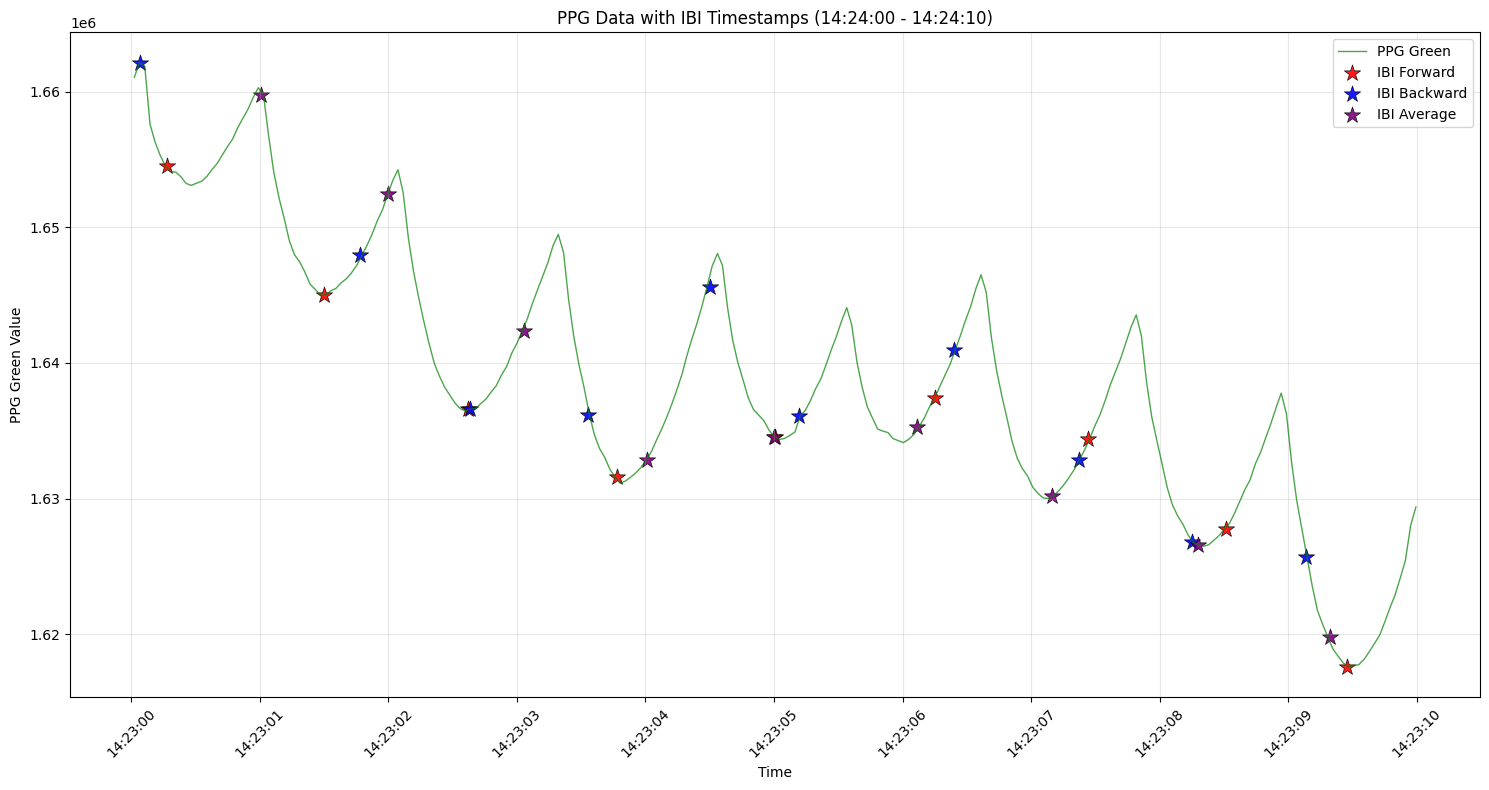

PPG data points: 249
IBI Forward points: 9
IBI Backward points: 10
IBI Average points: 9
Average timestamps: [Timestamp('2025-07-16 14:23:01.011000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:01.998000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:03.053000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:04.013000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:04.998000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:06.115000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:07.161000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:08.297000-0700', tz='US/Pacific'), Timestamp('2025-07-16 14:23:09.325000-0700', tz='US/Pacific')]


In [12]:
# Convert to US/Pacific timezone for filtering
pacific = pytz.timezone('US/Pacific')
start_time = pacific.localize(datetime(2025, 7, 16, 14, 23, 0))
end_time = pacific.localize(datetime(2025, 7, 16, 14, 23, 10))

# Filter data to the specified time range
ppg_filtered = ppg_data[(ppg_data['datetime'] >= start_time) & (ppg_data['datetime'] <= end_time)]
ibi_forward_filtered = ibi_data_forward[(ibi_data_forward['datetime'] >= start_time) & (ibi_data_forward['datetime'] <= end_time)]
ibi_backward_filtered = ibi_data_backward[(ibi_data_backward['datetime'] >= start_time) & (ibi_data_backward['datetime'] <= end_time)]
ibi_average_filtered = ibi_data_average[(ibi_data_average['datetime'] >= start_time) & (ibi_data_average['datetime'] <= end_time)]

# Create the plot
plt.figure(figsize=(15, 8))

# Plot PPG data as a curve
plt.plot(ppg_filtered['datetime'], ppg_filtered['ppg_green_value'], 
         label='PPG Green', color='green', linewidth=1, alpha=0.7)

# Function to get PPG value at a specific timestamp (interpolate if needed)
def get_ppg_value_at_time(timestamp, ppg_df):
    # Find the closest PPG measurement to the timestamp
    time_diff = abs(ppg_df['datetime'] - timestamp)
    closest_idx = time_diff.idxmin()
    return ppg_df.loc[closest_idx, 'ppg_green_value']

# Get PPG values for each IBI timestamp
forward_ppg_values = [get_ppg_value_at_time(timestamp, ppg_filtered) for timestamp in ibi_forward_filtered['datetime']]
backward_ppg_values = [get_ppg_value_at_time(timestamp, ppg_filtered) for timestamp in ibi_backward_filtered['datetime']]
average_ppg_values = [get_ppg_value_at_time(timestamp, ppg_filtered) for timestamp in ibi_average_filtered['datetime']]

# Plot IBI timestamps as stars on the PPG curve with different sizes and edge colors
plt.scatter(ibi_forward_filtered['datetime'], forward_ppg_values, 
           color='red', marker='*', s=150, label='IBI Forward', alpha=0.9, edgecolors='black', linewidth=0.5)
plt.scatter(ibi_backward_filtered['datetime'], backward_ppg_values, 
           color='blue', marker='*', s=150, label='IBI Backward', alpha=0.9, edgecolors='black', linewidth=0.5)
plt.scatter(ibi_average_filtered['datetime'], average_ppg_values, 
           color='purple', marker='*', s=150, label='IBI Average', alpha=0.9, edgecolors='black', linewidth=0.5)

plt.xlabel('Time')
plt.ylabel('PPG Green Value')
plt.title('PPG Data with IBI Timestamps (14:24:00 - 14:24:10)')
plt.legend()
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"PPG data points: {len(ppg_filtered)}")
print(f"IBI Forward points: {len(ibi_forward_filtered)}")
print(f"IBI Backward points: {len(ibi_backward_filtered)}")
print(f"IBI Average points: {len(ibi_average_filtered)}")

# Check if there are any average points
if len(ibi_average_filtered) == 0:
    print("No IBI average points found in this time range!")
else:
    print(f"Average timestamps: {ibi_average_filtered['datetime'].tolist()}")